<a href="https://colab.research.google.com/github/BrayFlo/Mineria-Datos/blob/main/Decision_Arbol2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [4]:
datos = {
    "Fiebre": ["Alta", "Alta", "Alta", "Normal", "Normal" ,"Normal", "Alta", "Normal"],
    "Tos": ["Si", "Si", "No", "Si", "No", "Si", "No", "No"],
    "Dolor":["Si", "No", "Si", "Si", "No", "No", "No", "Si"],
    "Gripe":["Si", "Si", "Si", "Si","No", "No", "No", "No"]
}

df = pd.DataFrame(datos)
df

,Fiebre,Tos,Dolor,Gripe
0,Alta,Si,Si,Si
1,Alta,Si,No,Si
2,Alta,No,Si,Si
3,Normal,Si,Si,Si
4,Normal,No,No,No
5,Normal,Si,No,No
6,Alta,No,No,No
7,Normal,No,Si,No


In [13]:
#Preprocesamiento de datos
le = LabelEncoder()

df_encoded = df.copy()
encoders = {}

for columna in ["Fiebre", "Tos", "Dolor", "Gripe"]:
    encoders[columna] = LabelEncoder()
    df_encoded[columna] = encoders[columna].fit_transform(df[columna])

df_encoded
#

,Fiebre,Tos,Dolor,Gripe
0,0,1,1,1
1,0,1,0,1
2,0,0,1,1
3,1,1,1,1
4,1,0,0,0
5,1,1,0,0
6,0,0,0,0
7,1,0,1,0


In [14]:
#3 Separar features y variable objetivo
atributos = ["Fiebre", "Tos", "Dolor"]
X = df_encoded[atributos]
y = df_encoded["Gripe"]

In [15]:
#4 Entrenar el arbol con entropia (equivalente a id3)

modelo = DecisionTreeClassifier(
    criterion="entropy", #usa entropia como id3
    random_state=123
)
modelo.fit(X, y)

print(f"Profundidad del arbol: {modelo.get_depth()}")
print(f"Numero de hojas: {modelo.get_n_leaves()}")

Profundidad del arbol: 3
Numero de hojas: 6


In [16]:
# Impoetancia de atributos (Equivalente a Ganancia)

importancias = pd.Series(
    modelo.feature_importances_,
    index=atributos
).sort_values(ascending=False)

for atributo, valor in importancias.items():
  print(f" {atributo}: {valor:.4f}")
  print()

 Fiebre: 0.4056

 Tos: 0.4056

 Dolor: 0.1887



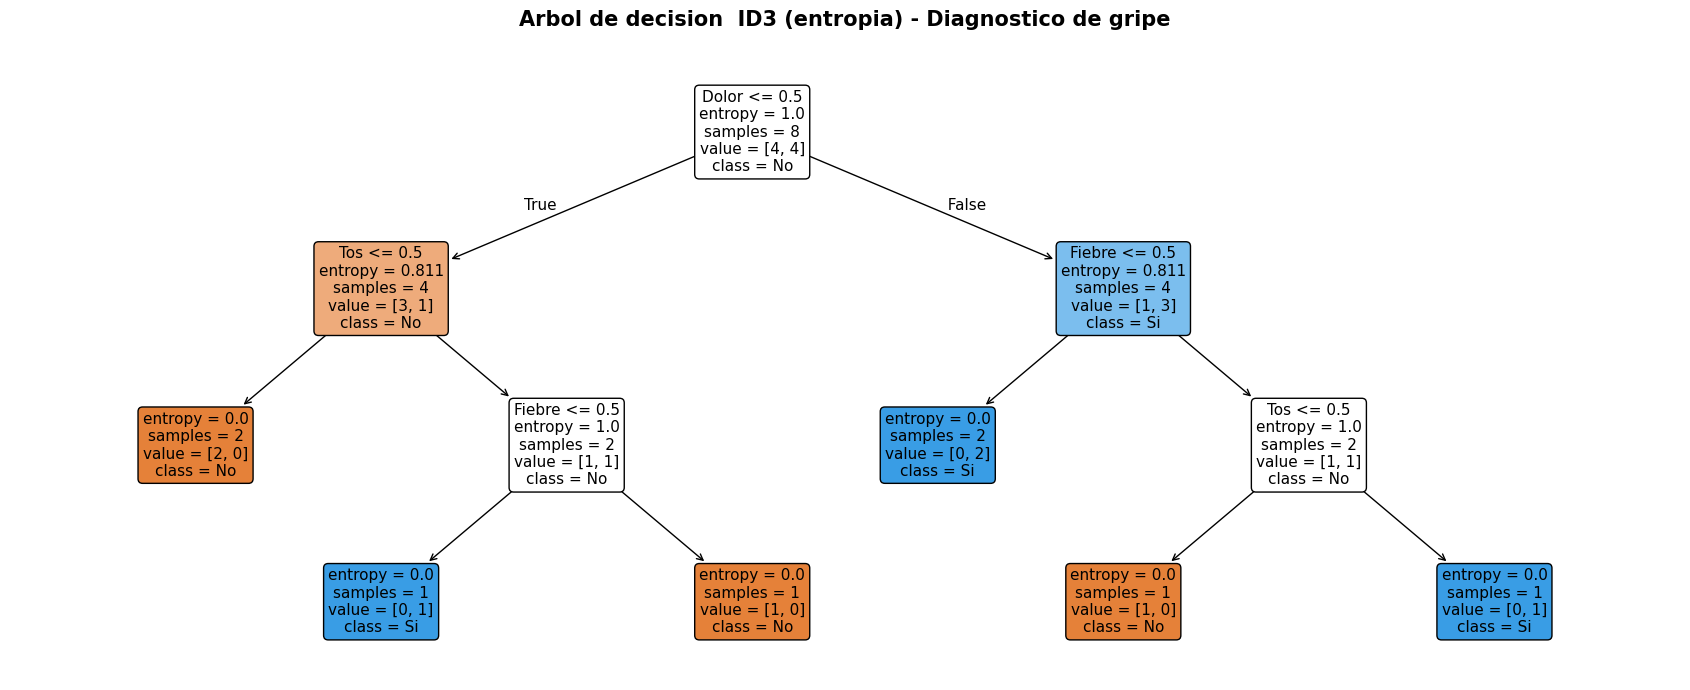

In [17]:
#Grafica 1: Arbol de decision con plot_free

fig1, ax1 = plt.subplots(figsize=(17, 7))
plot_tree(
    modelo,
    feature_names=atributos,
    class_names=encoders["Gripe"].classes_,
    filled=True,
    rounded=True,
    fontsize=11,
    ax=ax1,
    impurity=True,
    proportion=False
)

ax1.set_title(
    "Arbol de decision  ID3 (entropia) - Diagnostico de gripe",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()